# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

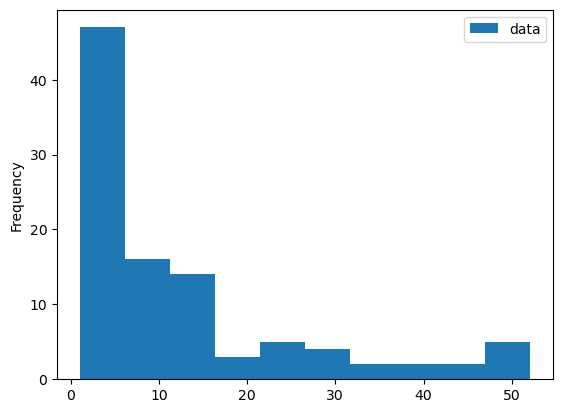

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

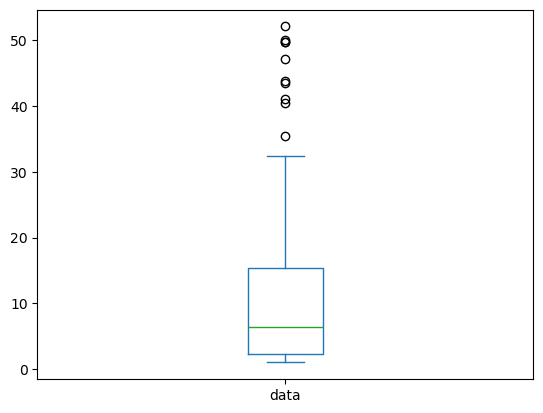

In [3]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

## Dataset 1 -E commerce

In [4]:
df1 = pd.read_csv("dataset1_clean.csv")

In [5]:
df1.shape

(5630, 29)

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CustomerID                           5630 non-null   int64  
 1   Churn                                5630 non-null   int64  
 2   Tenure                               5630 non-null   float64
 3   CityTier                             5630 non-null   int64  
 4   WarehouseToHome                      5630 non-null   float64
 5   HourSpendOnApp                       5630 non-null   float64
 6   NumberOfDeviceRegistered             5630 non-null   int64  
 7   SatisfactionScore                    5630 non-null   int64  
 8   NumberOfAddress                      5630 non-null   int64  
 9   Complain                             5630 non-null   int64  
 10  OrderAmountHikeFromlastYear          5630 non-null   float64
 11  CouponUsed                    

In [7]:
df1.columns

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
       'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone',
       'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card',
       'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI',
       'Gender_Male', 'PreferedOrderCat_Grocery',
       'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
       'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others',
       'MaritalStatus_Married', 'MaritalStatus_Single'],
      dtype='object')

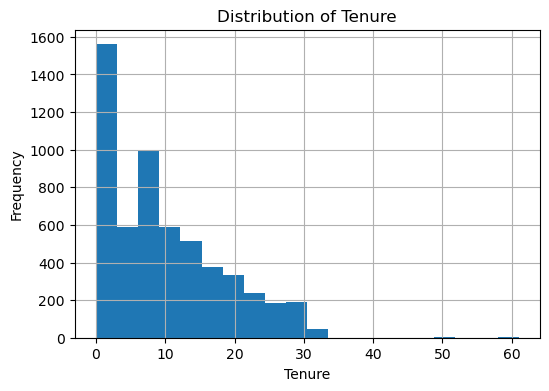

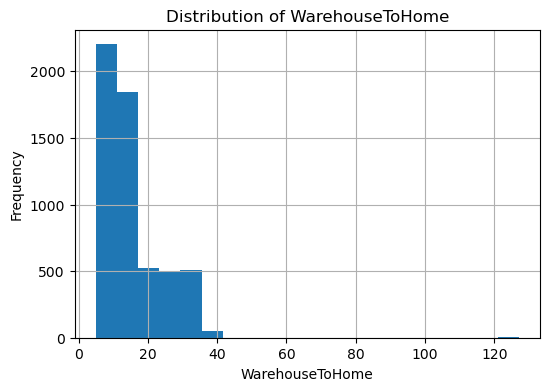

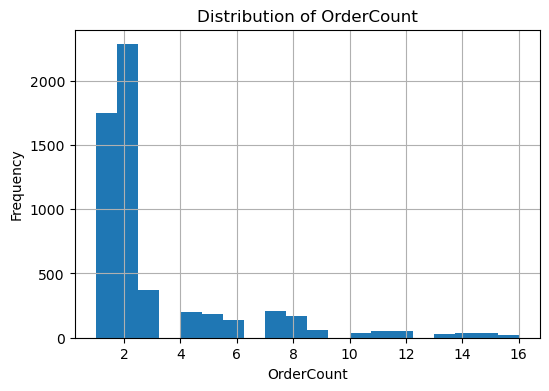

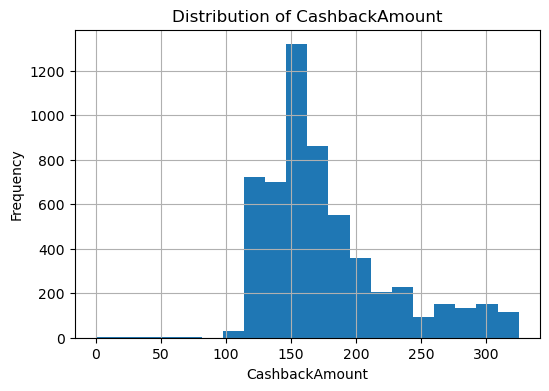

In [8]:
import matplotlib.pyplot as plt 

numeric_cols = [
    'Tenure',
    'WarehouseToHome',
    'OrderCount',
    'CashbackAmount'
]
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df1[col].hist(bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [9]:
for col in numeric_cols:
    print(f"\n----- {col} -----")
    print("Mean:", round(df1[col].mean(),2))
    print("Median:", round(df1[col].median(), 2))
    print("Mode:", df1[col].mode()[0])


----- Tenure -----
Mean: 10.13
Median: 9.0
Mode: 1.0

----- WarehouseToHome -----
Mean: 15.57
Median: 14.0
Mode: 9.0

----- OrderCount -----
Mean: 2.96
Median: 2.0
Mode: 2.0

----- CashbackAmount -----
Mean: 177.22
Median: 163.28
Mode: 123.42


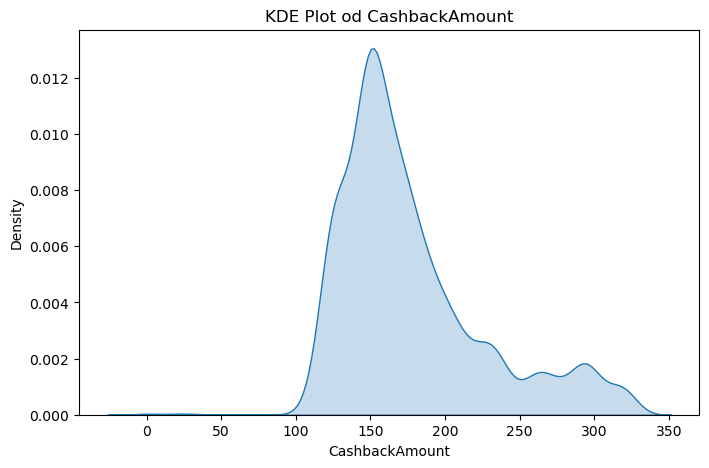

In [10]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df1['CashbackAmount'], fill=True)
plt.title('KDE Plot od CashbackAmount')
plt.show()

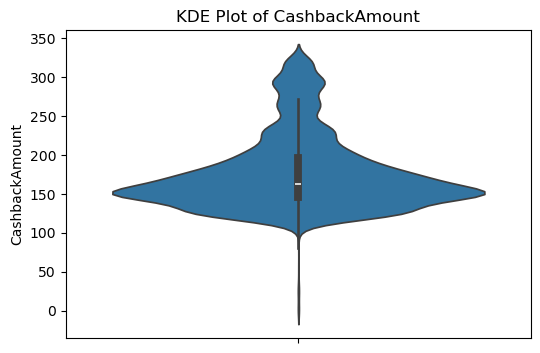

In [13]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df1['CashbackAmount'], fill=True)
plt.title('KDE Plot of CashbackAmount')
plt.show()

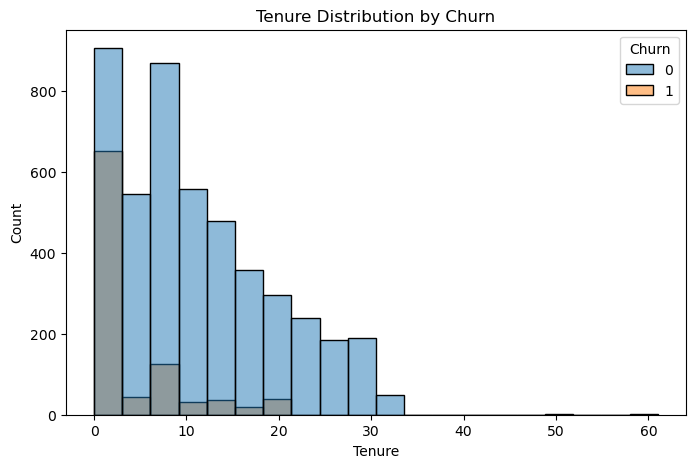

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df1,
    x='Tenure',
    hue='Churn',
    bins=20,
    multiple='layer')
plt.title('Tenure Distribution by Churn')
plt.show()

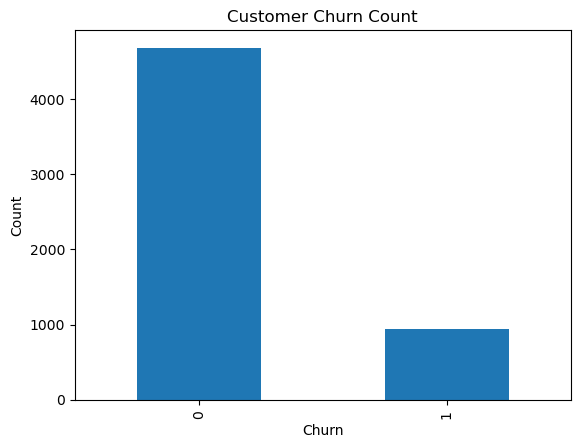

In [15]:
df1['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Count')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

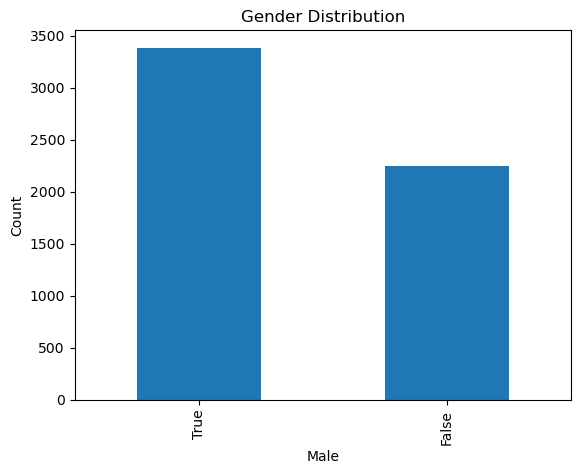

In [16]:
df1['Gender_Male'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Male')
plt.ylabel('Count')
plt.show()

### Dataset 1 Conclusion:

Based on the histograms and other visualizations, most of the variables do not follow a normal distribution and are skewed to the right. For example, Tenure and OrderCount show that most customers have lower values, while only a small number of customers have much higher values.

The WarehouseToHome variable shows that most customers live relatively close to the warehouse, with only a few customers located farther away. CashbackAmount is more concentrated around the middle values but still shows some skewness.

The grouped histogram suggests that customers with lower tenure seem to have a higher tendency to churn. The bar chart also shows that the majority of customers did not churn.

Overall, the dataset looks clean and useful for analysis. The visualizations helped identify the distribution of the variables and showed some interesting patterns related to customer behavior and churn.

## Dataset 2:

In [18]:
df2 = pd.read_csv("dataset2_clean.csv")

C:\Users\azade\AppData\Local\Temp\ipykernel_4464\1592011493.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("dataset2_clean.csv")


In [19]:
df2.shape

(51289, 48)

In [20]:
df2.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        51289 non-null  object 
 1   Customer Name                      51289 non-null  object 
 2   City                               51289 non-null  object 
 3   State                              51289 non-null  object 
 4   Country                            51289 non-null  object 
 5   Age                                51289 non-null  int64  
 6   Order ID                           51289 non-null  object 
 7   Order Date                         51289 non-null  object 
 8   Months                             51289 non-null  object 
 9   Product                            51289 non-null  object 
 10  Sales                              51288 non-null  float64
 11  Quantity                           51289 non-null  obj

In [21]:
df2.columns

Index(['Customer ID', 'Customer Name', 'City', 'State', 'Country', 'Age',
       'Order ID', 'Order Date', 'Months', 'Product', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Shipping Cost', 'Browsing Time (min)', 'Like',
       'Share', 'Add to Cart', 'Segment_Corporate', 'Segment_Home Office',
       'Region_Canada', 'Region_Caribbean', 'Region_Central',
       'Region_Central Asia', 'Region_EMEA', 'Region_East', 'Region_North',
       'Region_North Asia', 'Region_Oceania', 'Region_South',
       'Region_Southeast Asia', 'Region_West', 'Gender_Male',
       'Education_Bachelor', 'Education_Doctorate', 'Education_High School',
       'Education_Master', 'Marital Status_Single', 'Ship Mode_Same Day',
       'Ship Mode_Second Class', 'Ship Mode_Standard Class',
       'Product Category_Electronic', 'Product Category_Fashion',
       'Product Category_Home & Furniture', 'Order Priority_High',
       'Order Priority_Low', 'Order Priority_Medium'],
      dtype='object')

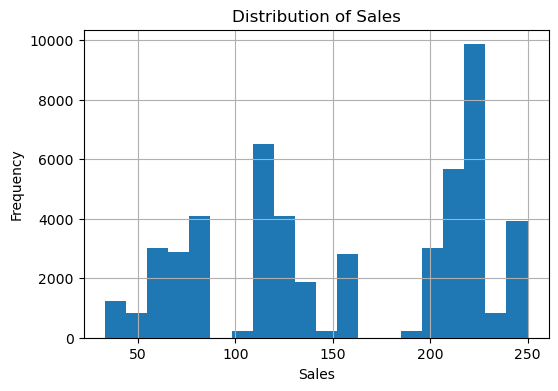

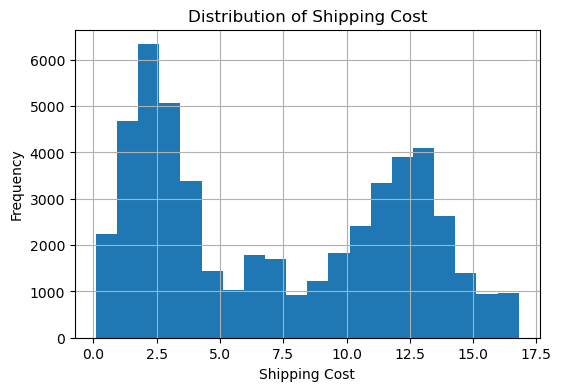

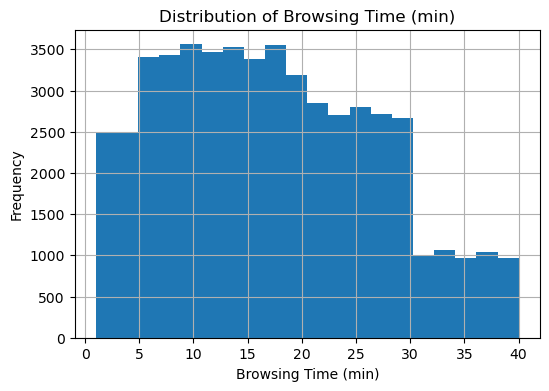

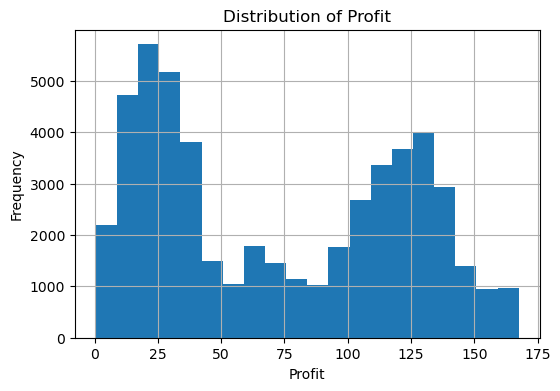

In [26]:
numeric_cols =[
    'Sales',
    'Shipping Cost',
    'Browsing Time (min)',
    'Profit'
]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df2[col].hist(bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [24]:
for col in numeric_cols:
    print(f"\n----- {col} -----")
    print("Mean:", round(df2[col].mean(),2))
    print("Median:", round(df2[col].median(),2))
    print("Mode:", df2[col].mode()[0])


----- Sales -----
Mean: 156.43
Median: 159.0
Mode: 228.0

----- Shipping Cost -----
Mean: 7.27
Median: 6.7
Mode: 2.1

----- Browsing Time (min) -----
Mean: 17.28
Median: 16.5
Mode: 7.4

----- Profit -----
Mean: 72.73
Median: 67.0
Mode: 17.0


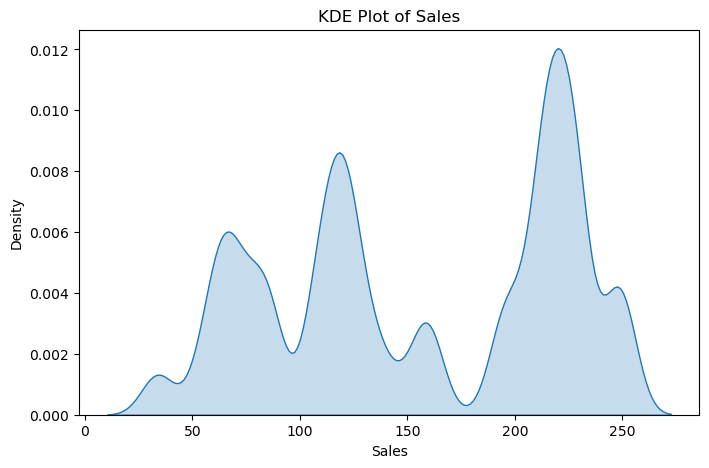

In [27]:

plt.figure(figsize=(8,5))
sns.kdeplot(df2['Sales'], fill=True)
plt.title('KDE Plot of Sales')
plt.show()

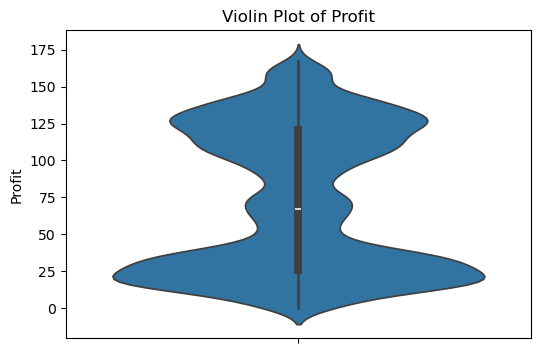

In [28]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df2['Profit'])
plt.title('Violin Plot of Profit')
plt.show()

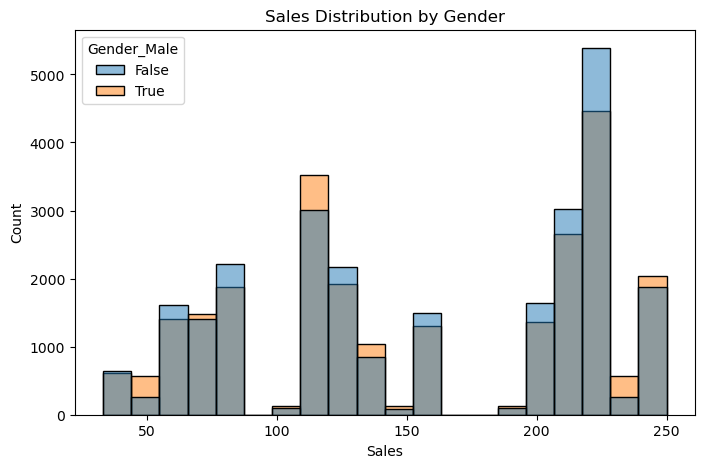

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df2,
    x='Sales',
    hue='Gender_Male',
    bins=20,
    multiple='layer'
)

plt.title('Sales Distribution by Gender')
plt.show()

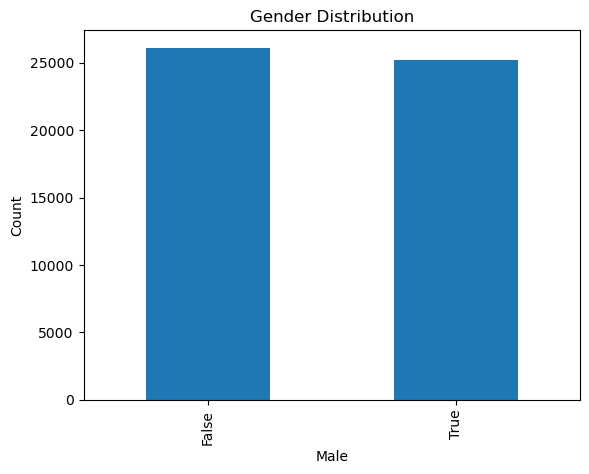

In [30]:
df2['Gender_Male'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Male')
plt.ylabel('Count')

plt.show()

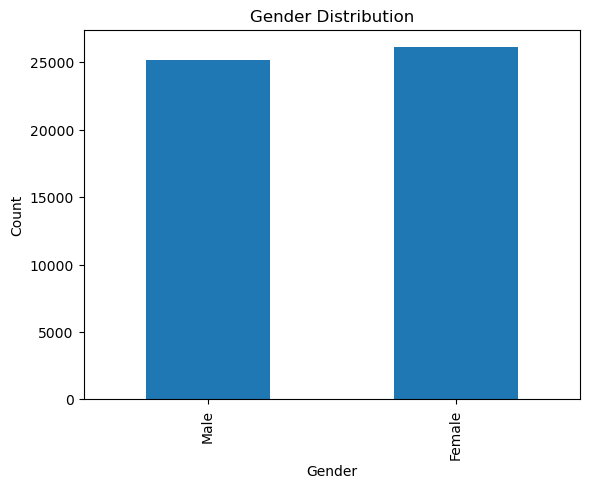

In [31]:
gender_counts = {
    'Male': df2['Gender_Male'].sum(),
    'Female': len(df2) - df2['Gender_Male'].sum()
}

pd.Series(gender_counts).plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Dataset 2 Conclusion:

This dataset contains over 51,000 customer transaction records and provides information about customer demographics, purchasing behavior, sales performance, and online engagement.

The distribution plots show that Sales and Profit are not evenly distributed and contain several peaks, suggesting that customers tend to fall into different spending groups rather than one uniform pattern. Shipping Cost also appears to have multiple clusters, indicating that different shipping methods or order types may exist in the dataset.

Browsing Time is spread across a wide range of values, showing that customers spend different amounts of time exploring products before making a purchase. Some customers spend only a few minutes browsing, while others remain on the website much longer.

The violin plot of Profit confirms that profits are concentrated around several ranges rather than a single central value. This suggests that some products or customer segments generate significantly different profit levels.

The gender distribution is relatively balanced, with a similar number of male and female customers. Additionally, the sales distribution by gender shows very similar patterns for both groups. This indicates that purchasing behavior does not appear to differ significantly between male and female customers in this dataset.

Overall, the dataset shows a diverse customer base with varying purchasing habits, browsing behavior, and profit contributions. These patterns suggest that customer segmentation and behavioral analysis could provide valuable insights for improving sales performance and marketing strategies.

## Dataset 3

In [32]:
df3 = pd.read_csv("dataset3_clean.csv")

In [33]:
df3.shape

(10000, 23)

In [34]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer_ID                         10000 non-null  object 
 1   Product_ID                          10000 non-null  object 
 2   Transaction_ID                      10000 non-null  object 
 3   Purchase_Frequency                  10000 non-null  int64  
 4   Average_Order_Value                 10000 non-null  float64
 5   Time_Between_Purchases              10000 non-null  int64  
 6   Churn_Probability                   10000 non-null  float64
 7   Lifetime_Value                      10000 non-null  float64
 8   Launch_Date                         10000 non-null  object 
 9   Peak_Sales_Date                     10000 non-null  object 
 10  Most_Frequent_Category_Electronics  10000 non-null  bool   
 11  Most_Frequent_Category_Home         10000 

In [35]:
df3.columns

Index(['Customer_ID', 'Product_ID', 'Transaction_ID', 'Purchase_Frequency',
       'Average_Order_Value', 'Time_Between_Purchases', 'Churn_Probability',
       'Lifetime_Value', 'Launch_Date', 'Peak_Sales_Date',
       'Most_Frequent_Category_Electronics', 'Most_Frequent_Category_Home',
       'Most_Frequent_Category_Sports', 'Region_Europe',
       'Region_North America', 'Region_South America', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Preferred_Purchase_Times_Evening',
       'Preferred_Purchase_Times_Morning', 'Retention_Strategy_Email Campaign',
       'Retention_Strategy_Loyalty Program'],
      dtype='object')

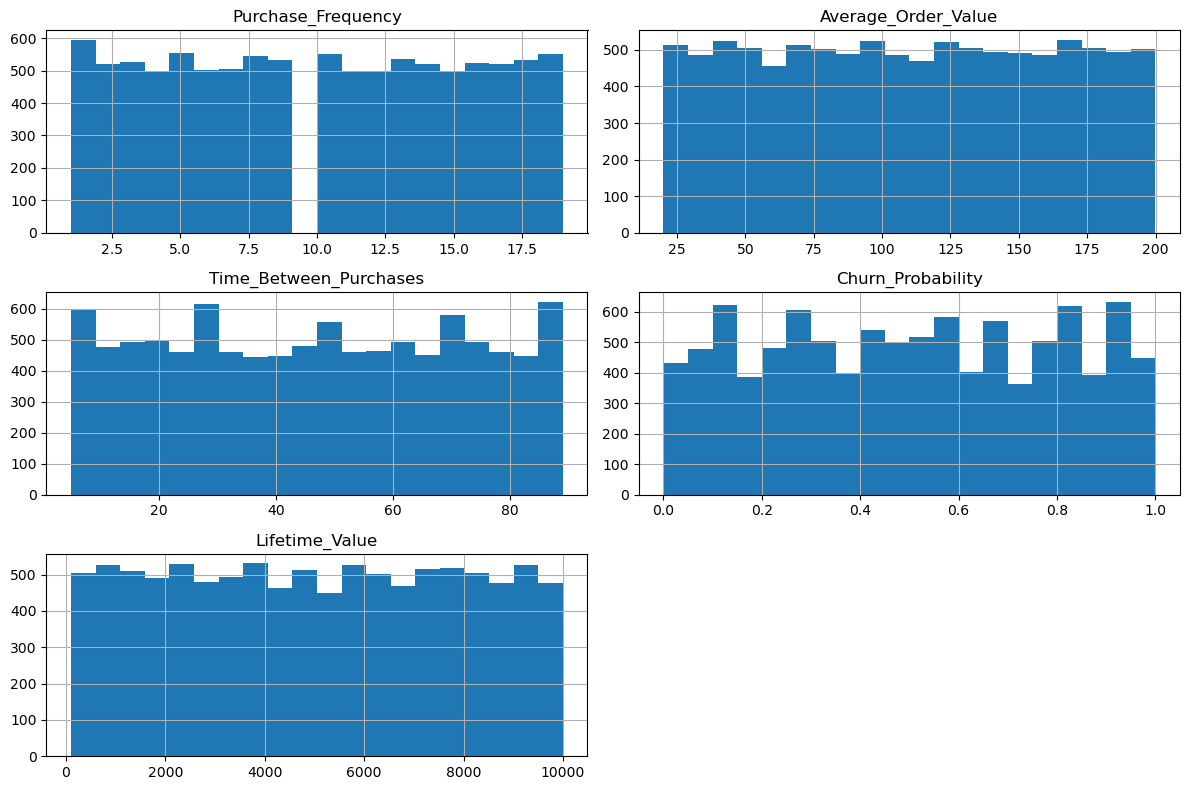

In [36]:
numeric_cols = [
    'Purchase_Frequency',
    'Average_Order_Value',
    'Time_Between_Purchases',
    'Churn_Probability',
    'Lifetime_Value'
]


df3[numeric_cols].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

In [37]:
for col in numeric_cols:
    print(f"\n----- {col} -----")
    print("Mean:", round(df3[col].mean(), 2))
    print("Median:", round(df3[col].median(), 2))
    print("Mode:", df3[col].mode()[0])


----- Purchase_Frequency -----
Mean: 9.96
Median: 10.0
Mode: 1

----- Average_Order_Value -----
Mean: 110.01
Median: 109.93
Mode: 26.74

----- Time_Between_Purchases -----
Mean: 46.89
Median: 47.0
Mode: 74

----- Churn_Probability -----
Mean: 0.5
Median: 0.5
Mode: 0.84

----- Lifetime_Value -----
Mean: 5031.93
Median: 5012.18
Mode: 138.63


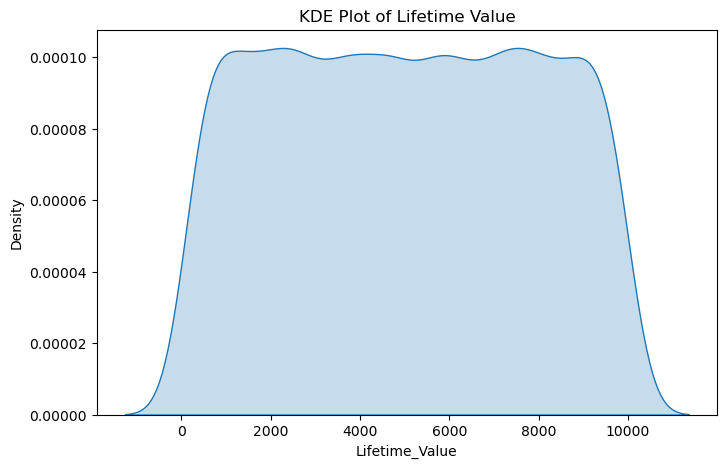

In [38]:

plt.figure(figsize=(8,5))
sns.kdeplot(df3['Lifetime_Value'], fill=True)

plt.title('KDE Plot of Lifetime Value')
plt.show()

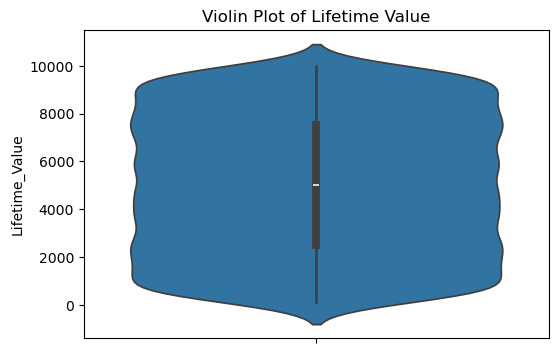

In [39]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df3['Lifetime_Value'])

plt.title('Violin Plot of Lifetime Value')
plt.show()

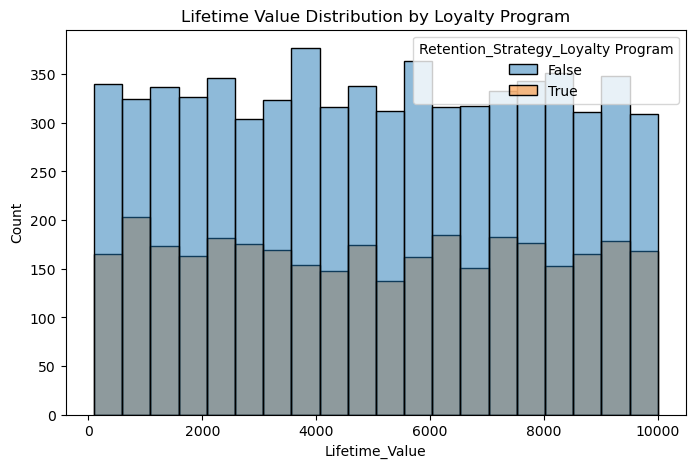

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df3,
    x='Lifetime_Value',
    hue='Retention_Strategy_Loyalty Program',
    bins=20,
    multiple='layer'
)

plt.title('Lifetime Value Distribution by Loyalty Program')
plt.show()

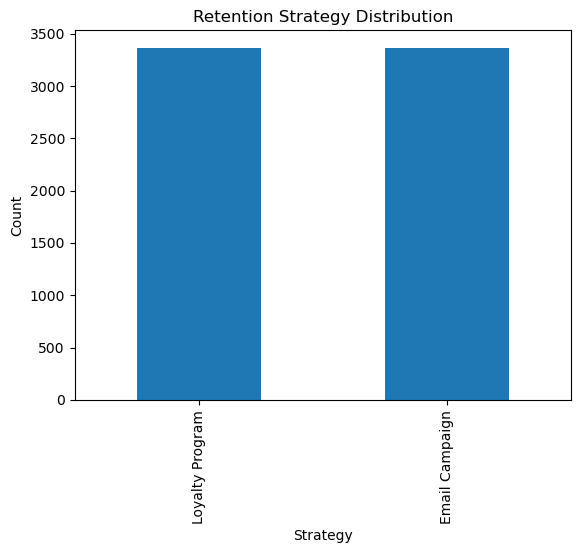

In [41]:
strategy_counts = {
    'Loyalty Program': df3['Retention_Strategy_Loyalty Program'].sum(),
    'Email Campaign': df3['Retention_Strategy_Email Campaign'].sum()
}

pd.Series(strategy_counts).plot(kind='bar')

plt.title('Retention Strategy Distribution')
plt.xlabel('Strategy')
plt.ylabel('Count')

plt.show()

### Dataset 3 Conclusion:

After exploring Dataset 3, I found that most numerical variables, including Purchase Frequency, Average Order Value, Time Between Purchases, Churn Probability, and Lifetime Value, are distributed very evenly across their ranges. The histograms, KDE plots, and violin plots show relatively flat and uniform patterns with very little skewness or clustering.

The summary statistics support this observation. For most variables, the mean and median values are almost identical, which indicates a highly balanced distribution. For example, Purchase Frequency has a mean of 9.96 and a median of 10, while Churn Probability has both a mean and median of 0.5. Lifetime Value also shows a very even spread across the entire range.

The Lifetime Value visualizations were particularly interesting. Both the KDE plot and violin plot suggest that customer values are spread almost uniformly from low to high values. In real-world customer data, we would normally expect to see more concentration in certain ranges and a smaller number of very high-value customers. However, that pattern is not visible here.

The comparison between customers participating in the Loyalty Program and those who are not also showed very similar distributions. Likewise, the Retention Strategy chart indicated that Loyalty Program and Email Campaign strategies were used at nearly the same rate. Because both groups appear so balanced, it is difficult to identify a strong relationship between retention strategy and customer value.

Overall, this dataset appears highly synthetic and artificially balanced. While it is useful for practicing data analysis techniques and visualization methods, it does not reflect the natural variability typically found in real customer behavior data. Therefore, any business conclusions drawn from this dataset should be interpreted with caution, as the patterns may be the result of how the data was generated rather than actual customer behavior.

## Dataset 4:

In [42]:
df4 = pd.read_csv("data4_clean.csv")

In [43]:
df4.shape

(49910, 72)

In [44]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49910 entries, 0 to 49909
Data columns (total 72 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            49910 non-null  float64
 1   Membership_Years               49910 non-null  float64
 2   Login_Frequency                49910 non-null  float64
 3   Session_Duration_Avg           49910 non-null  float64
 4   Pages_Per_Session              49910 non-null  float64
 5   Cart_Abandonment_Rate          49910 non-null  float64
 6   Wishlist_Items                 49910 non-null  float64
 7   Total_Purchases                49910 non-null  float64
 8   Average_Order_Value            49910 non-null  float64
 9   Days_Since_Last_Purchase       49910 non-null  float64
 10  Discount_Usage_Rate            49910 non-null  float64
 11  Returns_Rate                   49910 non-null  float64
 12  Email_Open_Rate                49910 non-null 

In [45]:
df4.columns

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Gender_Male', 'Gender_Other', 'Country_Canada',
       'Country_France', 'Country_Germany', 'Country_India', 'Country_Japan',
       'Country_UK', 'Country_USA', 'City_Bangalore', 'City_Berlin',
       'City_Birmingham', 'City_Brisbane', 'City_Calgary', 'City_Chennai',
       'City_Chicago', 'City_Cologne', 'City_Delhi', 'City_Frankfurt',
       'City_Glasgow', 'City_Hamburg', 'City_Houston', 'City_Hyderabad',
       'City_Kyoto', 'City_Leeds', 'City_London', 'City_Los Angeles',
       'City_Lyo

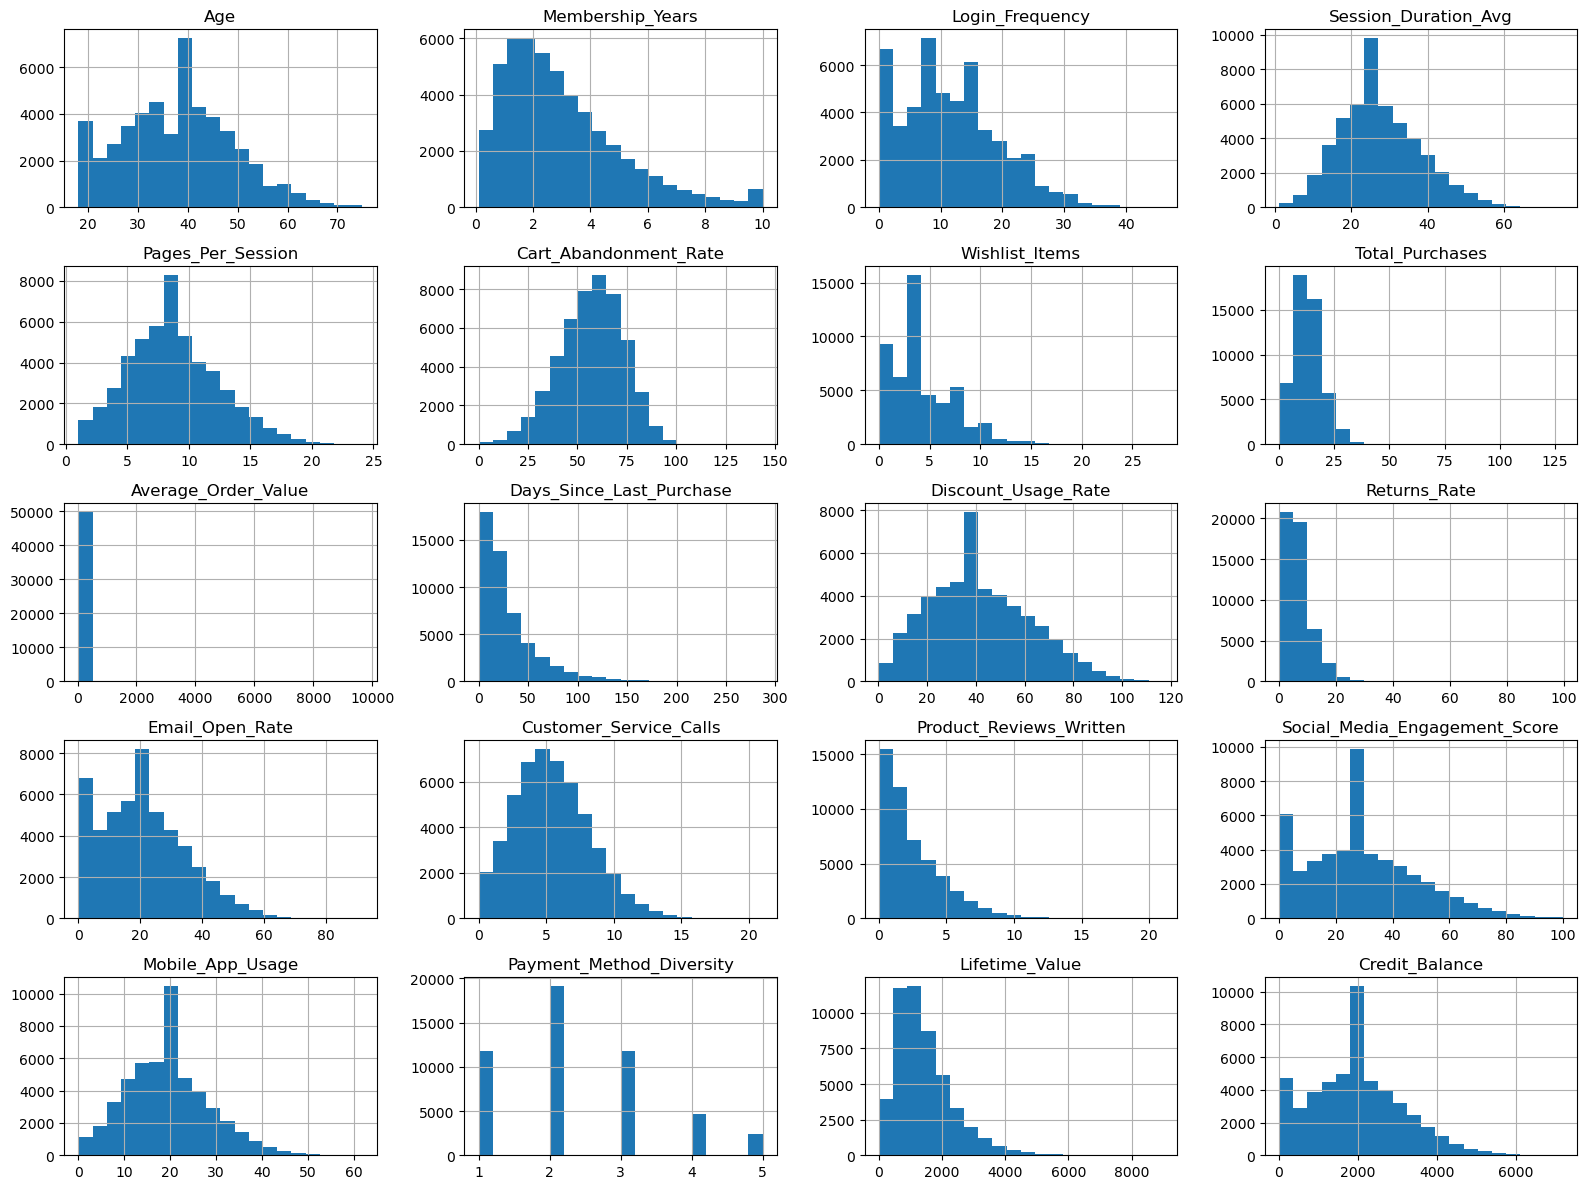

In [46]:
numeric_cols = [
    'Age',
    'Membership_Years',
    'Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Cart_Abandonment_Rate',
    'Wishlist_Items',
    'Total_Purchases',
    'Average_Order_Value',
    'Days_Since_Last_Purchase',
    'Discount_Usage_Rate',
    'Returns_Rate',
    'Email_Open_Rate',
    'Customer_Service_Calls',
    'Product_Reviews_Written',
    'Social_Media_Engagement_Score',
    'Mobile_App_Usage',
    'Payment_Method_Diversity',
    'Lifetime_Value',
    'Credit_Balance'
]

df4[numeric_cols].hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

In [47]:
for col in numeric_cols:
    print(f"\n----- {col} -----")
    print("Mean:", round(df4[col].mean(),2))
    print("Median:", round(df4[col].median(),2))
    print("Mode:", df4[col].mode()[0])


----- Age -----
Mean: 37.78
Median: 38.0
Mode: 38.0

----- Membership_Years -----
Mean: 2.98
Median: 2.5
Mode: 1.4

----- Login_Frequency -----
Mean: 11.63
Median: 11.0
Mode: 0.0

----- Session_Duration_Avg -----
Mean: 27.6
Median: 26.8
Mode: 26.8

----- Pages_Per_Session -----
Mean: 8.72
Median: 8.4
Mode: 8.4

----- Cart_Abandonment_Rate -----
Mean: 57.08
Median: 58.1
Mode: 57.3

----- Wishlist_Items -----
Mean: 4.27
Median: 4.0
Mode: 4.0

----- Total_Purchases -----
Mean: 13.13
Median: 12.0
Mode: 13.0

----- Average_Order_Value -----
Mean: 123.1
Median: 112.95
Mode: 95.88

----- Days_Since_Last_Purchase -----
Mean: 29.27
Median: 21.0
Mode: 21.0

----- Discount_Usage_Rate -----
Mean: 41.88
Median: 40.2
Mode: 40.2

----- Returns_Rate -----
Mean: 6.57
Median: 5.4
Mode: 5.4

----- Email_Open_Rate -----
Mean: 20.88
Median: 19.7
Mode: 0.0

----- Customer_Service_Calls -----
Mean: 5.68
Median: 5.0
Mode: 5.0

----- Product_Reviews_Written -----
Mean: 2.79
Median: 2.0
Mode: 2.0

----- Social

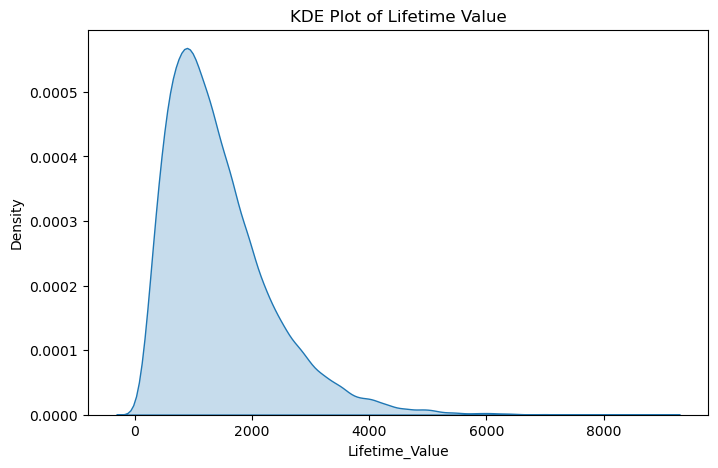

In [48]:


plt.figure(figsize=(8,5))
sns.kdeplot(df4['Lifetime_Value'], fill=True)

plt.title('KDE Plot of Lifetime Value')

plt.show()

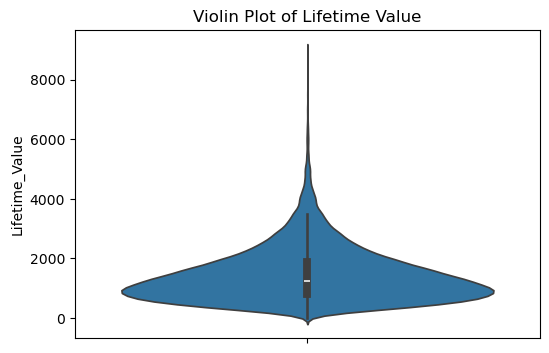

In [49]:
plt.figure(figsize=(6,4))

sns.violinplot(y=df4['Lifetime_Value'])

plt.title('Violin Plot of Lifetime Value')

plt.show()

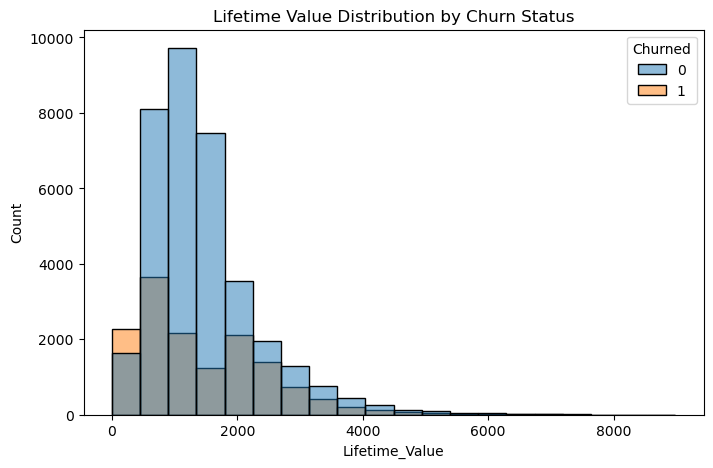

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df4,
    x='Lifetime_Value',
    hue='Churned',
    bins=20,
    multiple='layer'
)

plt.title('Lifetime Value Distribution by Churn Status')

plt.show()

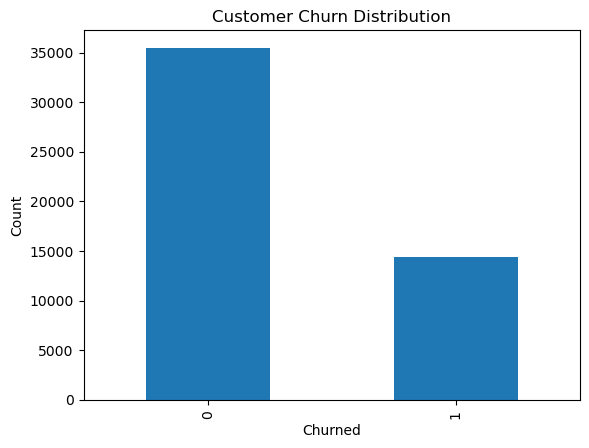

In [51]:
df4['Churned'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')

plt.show()

### Conclusion:

This dataset provides useful insights into customer behavior, engagement, purchasing patterns, and churn. Most variables show realistic distributions, such as Age, Session Duration, Membership Years, and Purchase Activity. The analysis indicates that most customers generate relatively low to moderate Lifetime Value, while a smaller group of customers contributes significantly higher value.

The churn analysis suggests that active customers generally have higher Lifetime Value compared to churned customers, which is consistent with expected business behavior. Additionally, customer engagement metrics such as login frequency, purchase activity, and mobile app usage show patterns that could be useful for future predictive modeling.

However, the dataset also appears to be partially synthetic. Several variables show very smooth and highly controlled distributions, which is uncommon in real-world customer data. While the dataset is valuable for learning, visualization, and modeling practice, the findings should be interpreted cautiously and may not fully represent real customer behavior.

Overall, the dataset is suitable for exploratory data analysis and machine learning exercises, but business conclusions should be validated using real-world customer data before making operational decisions.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

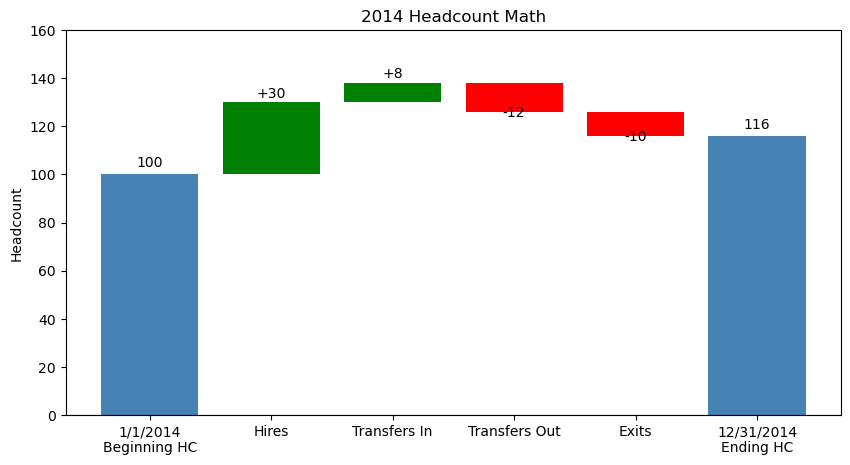

In [52]:


labels = ['1/1/2014\nBeginning HC', 'Hires', 'Transfers In', 
          'Transfers Out', 'Exits', '12/31/2014\nEnding HC']

values = [100, 30, 8, -12, -10, 116]

starts = [0, 100, 130, 138, 126, 0]
colors = ['steelblue', 'green', 'green', 'red', 'red', 'steelblue']

plt.figure(figsize=(10,5))

for i in range(len(labels)):
    if i == 0 or i == 5:
        plt.bar(labels[i], values[i], color=colors[i])
    else:
        plt.bar(labels[i], values[i], bottom=starts[i], color=colors[i])

plt.axhline(0, color='black', linewidth=0.8)

plt.title('2014 Headcount Math')
plt.ylabel('Headcount')
plt.xticks(rotation=0)
plt.ylim(0, 160)

plt.text(0, 103, '100', ha='center')
plt.text(1, 132, '+30', ha='center')
plt.text(2, 140, '+8', ha='center')
plt.text(3, 124, '-12', ha='center')
plt.text(4, 114, '-10', ha='center')
plt.text(5, 119, '116', ha='center')

plt.show()

I chose to reproduce the waterfall chart from the Storytelling With Data book. This chart shows how the headcount changed during 2014. It starts with 100 employees, then adds hires and transfers in, subtracts transfers out and exits, and ends with 116 employees. I tried to keep the same overall look and message of the original graph.